# Assignment 15 — Exercise Quality Score

## Important Notes
In our "real" training we use mlflow aswell as our previously trained models for start/stop and goodbad. This notebook instead uses the preprocessed files. This also does not include the manual testing for sanity checks as it also utilized dagshub/mlflow. 

## Imports

In [1]:
import os, glob, random, warnings, json
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.init as init
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import ReduceLROnPlateau
from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import MinMaxScaler
from scipy.stats import pearsonr, norm
import joblib
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')


## Helpers

In [2]:
def set_seed(seed=42):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

def get_feat_cols(columns):
    return [c for c in columns if '_3d_' in c]

def to_fixed_length(arr, c):
    n = len(arr)
    if n == c: return arr
    if n < c:
        return np.vstack([arr, np.zeros((c-n, arr.shape[1]), 'float32')])
    idx = np.round(np.linspace(0, n-1, c)).astype(int)
    return arr[idx]

KEY_DIST_PAIRS = [
    ('left_shoulder','right_shoulder'),('left_elbow','right_elbow'),
    ('left_wrist','right_wrist'),('left_hip','right_hip'),
    ('left_knee','right_knee'),('left_ankle','right_ankle'),
    ('left_shoulder','left_elbow'),('left_elbow','left_wrist'),
    ('right_shoulder','right_elbow'),('right_elbow','right_wrist'),
    ('left_hip','left_knee'),('left_knee','left_ankle'),
    ('right_hip','right_knee'),('right_knee','right_ankle'),
    ('left_shoulder','left_hip'),('right_shoulder','right_hip'),
]
KEY_ANGLE_TRIPLES = [
    ('left_shoulder','left_elbow','left_wrist'),
    ('right_shoulder','right_elbow','right_wrist'),
    ('left_hip','left_knee','left_ankle'),
    ('right_hip','right_knee','right_ankle'),
    ('left_elbow','left_shoulder','left_hip'),
    ('right_elbow','right_shoulder','right_hip'),
]

def _pos(arr, fc, joint):
    idxs = []
    for ax in ['x','y','z']:
        col = f'{joint}_3d_{ax}'
        if col not in fc: return None
        idxs.append(fc.index(col))
    return arr[:, idxs]

def add_features(arr, fc):
    extras = []
    pls = _pos(arr,fc,'left_shoulder'); prs = _pos(arr,fc,'right_shoulder')
    scale = np.linalg.norm(prs-pls,axis=1,keepdims=True).mean()+1e-8 if pls is not None and prs is not None else 1.0
    for j1,j2 in KEY_DIST_PAIRS:
        p1,p2 = _pos(arr,fc,j1),_pos(arr,fc,j2)
        if p1 is not None and p2 is not None:
            extras.append(np.linalg.norm(p2-p1,axis=1,keepdims=True)/scale)
    for ja,jv,jb in KEY_ANGLE_TRIPLES:
        pa,pv,pb = _pos(arr,fc,ja),_pos(arr,fc,jv),_pos(arr,fc,jb)
        if pa is not None and pv is not None and pb is not None:
            va,vb = pa-pv,pb-pv
            cos = (np.sum(va*vb,axis=1)/(np.linalg.norm(va,axis=1)*np.linalg.norm(vb,axis=1)+1e-8))
            extras.append(cos.reshape(-1,1))
    return np.hstack([arr]+extras).astype('float32') if extras else arr


## Setup

In [3]:
device    = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')


Device: cpu


## Load Scores

Scores: 180  range: 0.000 – 4.000  mean=2.000  std=0.7207


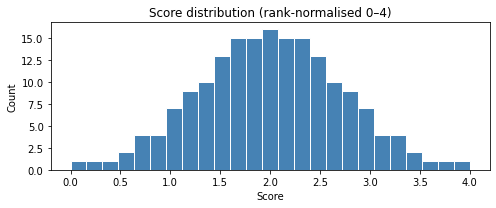

In [4]:
SCORE_MAX = 4.0

scores_df = pd.read_csv('datafiles/scores_a15.csv')
scores_df.columns = ['filename', 'score']
scores_df = scores_df.sort_values('score').reset_index(drop=True)
n = len(scores_df)
quantiles = (scores_df.index + 0.5) / n
scores_df['score'] = norm.ppf(quantiles)
scores_df['score'] = (scores_df['score'] - scores_df['score'].min()) / \
                     (scores_df['score'].max() - scores_df['score'].min()) * SCORE_MAX

scores_map = dict(zip(scores_df['filename'].str.replace('_kinect',''), scores_df['score']))

print(f'Scores: {len(scores_map)}  range: {scores_df.score.min():.3f} – {scores_df.score.max():.3f}  '
      f'mean={scores_df.score.mean():.3f}  std={scores_df.score.std():.4f}')
plt.figure(figsize=(7,3))
plt.hist(scores_df['score'], bins=25, color='steelblue', edgecolor='white')
plt.xlabel('Score'); plt.ylabel('Count'); plt.title('Score distribution (rank-normalised 0–4)')
plt.tight_layout();


## Load Data

In [5]:
DATA_DIR = 'datafiles/kinect_good_preprocessed_A9_mediapipe'
C        = 10

all_csv = sorted(glob.glob(os.path.join(DATA_DIR,'*.csv')))
print(f'Found {len(all_csv)} CSV files')

raw_sequences = []
skipped_score = []

for f in tqdm(all_csv, desc='Loading'):
    key = os.path.splitext(os.path.basename(f))[0].replace('_kinect','')
    if key not in scores_map:
        skipped_score.append(key); continue
    df        = pd.read_csv(f)
    feat_cols = get_feat_cols(df.columns)
    feat_arr  = df[feat_cols].values.astype('float32')
    raw_sequences.append((feat_arr, scores_map[key], f, feat_cols))

print(f'Kept: {len(raw_sequences)}  no score: {len(skipped_score)}')
FEAT_COLS = raw_sequences[0][3]


Found 179 CSV files


Loading: 100%|██████████| 179/179 [00:00<00:00, 500.33it/s]

Kept: 179  no score: 0


## Augmentation

In [6]:
LEFT_RIGHT_PAIRS = [
    ('left_shoulder','right_shoulder'),('left_elbow','right_elbow'),
    ('left_wrist','right_wrist'),('left_hip','right_hip'),
    ('left_knee','right_knee'),('left_ankle','right_ankle'),
]

def _col_idx(fc, joint, ax):
    try: return fc.index(f'{joint}_3d_{ax}')
    except ValueError: return -1

def aug_mirror(arr, fc):
    a = arr.copy()
    xi = [i for i,c in enumerate(fc) if c.endswith('_3d_x')]
    a[:,xi] = 1.0 - a[:,xi]
    for l,r in LEFT_RIGHT_PAIRS:
        for ax in ['x','y','z']:
            li,ri = _col_idx(fc,l,ax),_col_idx(fc,r,ax)
            if li==-1 or ri==-1: continue
            a[:,li],a[:,ri] = arr[:,ri].copy(),arr[:,li].copy()
            if ax=='x': a[:,li]=1-a[:,li]; a[:,ri]=1-a[:,ri]
    return a

def aug_rotate_y(arr, fc, deg):
    a=arr.copy(); t=np.radians(deg); c,s=np.cos(t),np.sin(t)
    xi=[i for i,col in enumerate(fc) if col.endswith('_3d_x')]
    zi=[i for i,col in enumerate(fc) if col.endswith('_3d_z')]
    for x,z in zip(xi,zi):
        xv,zv=arr[:,x].copy(),arr[:,z].copy()
        a[:,x]=c*xv+s*zv; a[:,z]=-s*xv+c*zv
    return a

def aug_scale(arr, fc, sx=1.0, sy=1.0, sz=1.0):
    a=arr.copy()
    for i,col in enumerate(fc):
        if col.endswith('_3d_x'): a[:,i]*=sx
        elif col.endswith('_3d_y'): a[:,i]*=sy
        elif col.endswith('_3d_z'): a[:,i]*=sz
    return a

def aug_noise(arr, sigma=0.005):
    return arr + np.random.normal(0,sigma,arr.shape).astype('float32')

def generate_variants(arr, fc):
    m = aug_mirror(arr,fc)
    return [
        arr, m,
        aug_rotate_y(arr,fc,-10), aug_rotate_y(arr,fc,-5),
        aug_rotate_y(arr,fc,5),   aug_rotate_y(arr,fc,10),
        aug_rotate_y(m,fc,-5),    aug_rotate_y(m,fc,5),
        aug_scale(arr,fc,0.95,0.95,0.95), aug_scale(arr,fc,1.05,1.05,1.05),
        aug_scale(m,fc,0.95,0.95,0.95),   aug_scale(m,fc,1.05,1.05,1.05),
        aug_noise(arr,0.005), aug_noise(arr,0.010), aug_noise(m,0.005),
    ]

augmented_pool = []
for gid,(arr,score,fpath,fc) in enumerate(tqdm(raw_sequences,desc='Augmenting')):
    for v in generate_variants(arr,fc):
        augmented_pool.append((v, score, gid))

N_VARIANTS_PER = len(generate_variants(raw_sequences[0][0], FEAT_COLS))
orig_indices   = np.arange(0, len(augmented_pool), N_VARIANTS_PER)
print(f'Pool: {len(augmented_pool)} sequences ({N_VARIANTS_PER} variants each)')


Augmenting: 100%|██████████| 179/179 [00:00<00:00, 712.26it/s]

Pool: 2685 sequences (15 variants each)


## Fixed-Size Sequences

In [7]:
X_seq, y_all, grp_all = [], [], []
for arr,score,gid in tqdm(augmented_pool,desc='Building sequences'):
    enriched = add_features(arr, FEAT_COLS)
    fixed    = to_fixed_length(enriched, C)
    X_seq.append(fixed); y_all.append(score); grp_all.append(gid)

X_seq   = np.array(X_seq,  dtype='float32')
X_flat  = X_seq.reshape(len(X_seq),-1)
y_all   = np.array(y_all,  dtype='float32')
grp_all = np.array(grp_all)

N_FEAT      = X_seq.shape[2]
INPUT_DENSE = X_flat.shape[1]
print(f'Shape: {X_seq.shape}  Dense input: {INPUT_DENSE}  Score range: {y_all.min():.2f}–{y_all.max():.2f}')


Building sequences: 100%|██████████| 2685/2685 [00:01<00:00, 2205.39it/s]

Shape: (2685, 10, 61)  Dense input: 610  Score range: 0.00–4.00


## Models

In [8]:
def count_params(m): return sum(p.numel() for p in m.parameters() if p.requires_grad)

class ADense(nn.Module):
    def __init__(self, input_dim, h1, h2, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim,h1), nn.BatchNorm1d(h1), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(h1,h2), nn.ReLU(), nn.Linear(h2,1))
        for m in self.modules():
            if isinstance(m,nn.Linear): init.xavier_uniform_(m.weight)
    def forward(self,x): return self.net(x)

class ACNN(nn.Module):
    def __init__(self, n_feat, seq_len, n_filters=8, kernel_size=3, pool_size=2, fc_h=16, dropout=0.3):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(n_feat,n_filters,kernel_size,padding=kernel_size//2),
            nn.ReLU(), nn.MaxPool1d(pool_size))
        co = n_filters*(seq_len//pool_size) if pool_size > 1 else n_filters*seq_len
        self.fc = nn.Sequential(nn.Flatten(),nn.Dropout(dropout),nn.Linear(co,fc_h),nn.ReLU(),nn.Linear(fc_h,1))
        for m in self.modules():
            if isinstance(m,nn.Linear): init.xavier_uniform_(m.weight)
            elif isinstance(m,nn.Conv1d): init.kaiming_normal_(m.weight)
    def forward(self,x): return self.fc(self.conv(x.permute(0,2,1)))

class ARNN(nn.Module):
    def __init__(self, n_feat, hidden=32, num_layers=1, rnn_type='GRU', dropout=0.0):
        super().__init__()
        rnn_cls  = nn.GRU if rnn_type=='GRU' else nn.LSTM
        self.rnn = rnn_cls(n_feat,hidden,num_layers,batch_first=True,
                           dropout=dropout if num_layers>1 else 0)
        self.fc  = nn.Linear(hidden,1)
        init.xavier_uniform_(self.fc.weight)
    def forward(self,x):
        out,_ = self.rnn(x); return self.fc(out[:,-1,:])

_h1 = max(8, int(9000/INPUT_DENSE))
_h2 = max(4, _h1//2)
print(f'ADense {count_params(ADense(INPUT_DENSE,_h1,_h2)):,}  '
      f'ACNN {count_params(ACNN(N_FEAT,C)):,}  '
      f'ARNN {count_params(ARNN(N_FEAT)):,}')


ADense 8,695  ACNN 2,145  ARNN 9,153


## Training Utilities

In [9]:
from contextlib import nullcontext

class ScoreDataset(Dataset):
    def __init__(self,X,y):
        self.X=torch.tensor(X,dtype=torch.float32)
        self.y=torch.tensor(y,dtype=torch.float32).unsqueeze(1)
    def __len__(self): return len(self.y)
    def __getitem__(self,i): return self.X[i],self.y[i]

def run_epoch(model, loader, optimizer, criterion, device, train=True):
    model.train() if train else model.eval()
    total_loss=0.0; preds=[]; targets=[]
    ctx = nullcontext() if train else torch.no_grad()
    with ctx:
        for xb,yb in loader:
            xb,yb=xb.to(device),yb.to(device)
            if train: optimizer.zero_grad()
            out=model(xb); loss=criterion(out,yb)
            if train: loss.backward(); optimizer.step()
            total_loss+=loss.item()
            preds.extend(out.detach().cpu().numpy().flatten())
            targets.extend(yb.cpu().numpy().flatten())
    p=np.array(preds); t=np.array(targets)
    return total_loss/len(loader), float(np.mean((p-t)**2)), float(np.mean(np.abs(p-t)))

def evaluate(model, loader, device):
    model.eval(); preds=[]; targets=[]
    with torch.no_grad():
        for xb,yb in loader:
            preds.extend(model(xb.to(device)).cpu().numpy().flatten())
            targets.extend(yb.numpy().flatten())
    p=np.array(preds); t=np.array(targets)
    mse=float(np.mean((p-t)**2)); mae=float(np.mean(np.abs(p-t)))
    return {'MSE':mse,'MAE':mae,'RMSE':float(np.sqrt(mse)),'preds':p,'targets':t}

def _pad(lst,n):
    return lst+[lst[-1]]*(n-len(lst)) if lst else [0.0]*n

def plot_curves(histories, note, n_params):
    max_ep=max(len(h['tl']) for h in histories)
    e=np.arange(1,max_ep+1)
    def avg(k): return np.mean([_pad(h[k],max_ep) for h in histories],axis=0)
    fig,axes=plt.subplots(1,3,figsize=(14,4))
    fig.suptitle(f'{note}  ({n_params:,} params)')
    for ax,(tk,vk,lbl) in zip(axes,[('tl','vl','Loss'),('tm','vm','MSE'),('ta','va','MAE')]):
        ax.plot(e,avg(tk),'-',label='Train',color='steelblue')
        ax.plot(e,avg(vk),'--',label='Val',color='steelblue',alpha=0.7)
        ax.set_xlabel('Epoch'); ax.set_title(lbl); ax.legend(); ax.grid(alpha=0.3)
    plt.tight_layout()

def plot_evaluation(preds, targets, note, metrics):
    fig,axes=plt.subplots(1,3,figsize=(16,4))
    fig.suptitle(f'{note} — MSE={metrics["MSE"]:.4f}  MAE={metrics["MAE"]:.4f}  RMSE={metrics["RMSE"]:.4f}')
    r,_ = pearsonr(targets,preds)
    lo,hi = min(targets.min(),preds.min()),max(targets.max(),preds.max())
    axes[0].scatter(targets,preds,alpha=0.5,color='steelblue',s=15)
    axes[0].plot([lo,hi],[lo,hi],'r--',lw=1)
    axes[0].set_xlabel('True score'); axes[0].set_ylabel('Predicted score')
    axes[0].set_title(f'Pred vs True  r={r:.3f}')
    mean_val=(preds+targets)/2; diff=preds-targets
    md_val=diff.mean(); sd_val=diff.std()
    axes[1].scatter(mean_val,diff,alpha=0.5,color='steelblue',s=15)
    axes[1].axhline(md_val,color='red',lw=1.5,label=f'Mean {md_val:.3f}')
    axes[1].axhline(md_val+1.96*sd_val,color='red',lw=1,linestyle='--',label='+1.96 SD')
    axes[1].axhline(md_val-1.96*sd_val,color='red',lw=1,linestyle='--',label='-1.96 SD')
    axes[1].axhline(0,color='gray',lw=0.8)
    axes[1].set_xlabel('Mean of pred & true'); axes[1].set_ylabel('Pred - True')
    axes[1].set_title('Bland-Altman'); axes[1].legend(fontsize=7)
    axes[2].hist(diff,bins=20,color='steelblue',edgecolor='white')
    axes[2].axvline(0,color='red',linestyle='--')
    axes[2].set_xlabel('Residual'); axes[2].set_title('Residuals')
    plt.tight_layout()


## Experiment Configuration

In [10]:
N_FOLDS = 10
SEED    = 42
set_seed(SEED)

ALL_VARIANTS = [
    {'note':'ADense_v3_large','model_type':'dense','h1':_h1+4,'h2':_h2+2,'dropout':0.2,
     'lr':1e-3,'batch_size':32,'epochs':120,'patience':15,'use_scaling':True},
]
print(f'{len(ALL_VARIANTS)} variants')


1 variants


## Training

  Fold  1 | MSE=0.3343  MAE=0.4208  RMSE=0.5782
  Fold  2 | MSE=0.2697  MAE=0.4363  RMSE=0.5193
  Fold  3 | MSE=0.3446  MAE=0.4837  RMSE=0.5871
  Fold  4 | MSE=0.2318  MAE=0.3621  RMSE=0.4814
  Fold  5 | MSE=0.1377  MAE=0.2982  RMSE=0.3710
  Fold  6 | MSE=0.1658  MAE=0.3205  RMSE=0.4071
  Fold  7 | MSE=0.2020  MAE=0.3803  RMSE=0.4495
  Fold  8 | MSE=0.2487  MAE=0.3225  RMSE=0.4987
  Fold  9 | MSE=0.3953  MAE=0.5075  RMSE=0.6287
  Fold 10 | MSE=0.7559  MAE=0.5707  RMSE=0.8694

--- ADense_v3_large (11,215 params) ---
10-fold: MSE=0.3086  MAE=0.4103  RMSE=0.5390  r=0.6863
New best: ADense_v3_large  MAE=0.4103


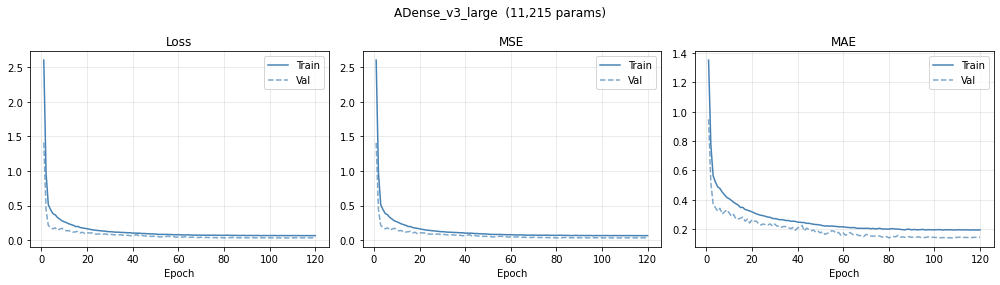

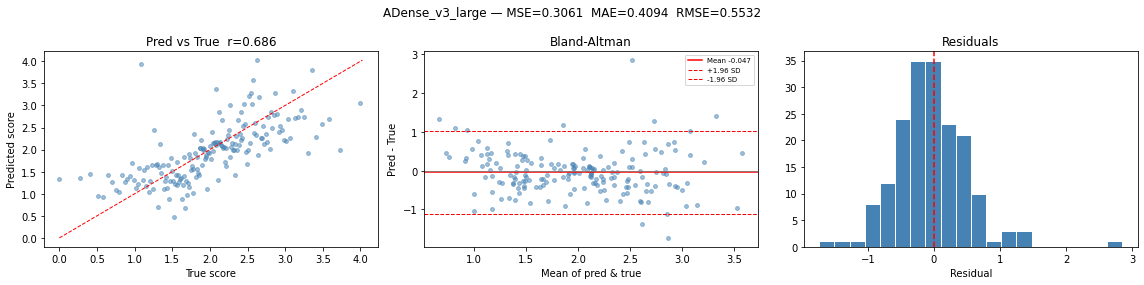

In [11]:
def build_model(config):
    mt = config['model_type']
    if mt=='dense': return ADense(INPUT_DENSE,config['h1'],config['h2'],config['dropout'])
    if mt=='cnn':   return ACNN(N_FEAT,C,config['n_filters'],config['kernel_size'],
                                config['pool_size'],config['fc_h'],config['dropout'])
    return ARNN(N_FEAT,config['hidden'],config['num_layers'],config['rnn_type'],config['dropout'])

def get_X(config, indices):
    return X_flat[indices] if config['model_type']=='dense' else X_seq[indices]

all_variant_results = []
best_global_mae     = float('inf')

for config in ALL_VARIANTS:
    set_seed(SEED)
    note        = config['note']

    _demo    = build_model(config)
    n_params = count_params(_demo); del _demo

    gkf         = GroupKFold(n_splits=N_FOLDS)
    orig_groups = grp_all[orig_indices]
    orig_y      = y_all[orig_indices]

    fold_results=[]; fold_histories=[]
    agg_preds=[]; agg_targets=[]
    best_overall_mse=float('inf')

    for fold,(tr_orig,te_orig) in enumerate(gkf.split(orig_indices,orig_y,orig_groups)):
        train_groups=set(orig_groups[tr_orig])
        test_groups =set(orig_groups[te_orig])

        train_mask=np.array([g in train_groups for g in grp_all])
        orig_set  =set(orig_indices.tolist())
        test_mask =np.array([idx in orig_set and grp_all[idx] in test_groups
                              for idx in range(len(grp_all))])

        X_tr_raw=get_X(config,np.where(train_mask)[0]); y_tr=y_all[train_mask]
        X_te_raw=get_X(config,np.where(test_mask)[0]);  y_te=y_all[test_mask]

        scaler=None
        if config.get('use_scaling'):
            scaler=MinMaxScaler()
            flat_tr=X_tr_raw.reshape(len(X_tr_raw),-1)
            scaler.fit(flat_tr)
            X_tr_s=scaler.transform(flat_tr).reshape(X_tr_raw.shape)
            X_te_s=scaler.transform(X_te_raw.reshape(len(X_te_raw),-1)).reshape(X_te_raw.shape)
        else:
            X_tr_s,X_te_s=X_tr_raw,X_te_raw

        shuf=np.random.permutation(len(X_tr_s))
        X_tr_s=X_tr_s[shuf]; y_tr=y_tr[shuf]
        val_split=int(len(X_tr_s)*0.9)
        X_t,X_v=X_tr_s[:val_split],X_tr_s[val_split:]
        y_t,y_v=y_tr[:val_split],y_tr[val_split:]

        train_loader=DataLoader(ScoreDataset(X_t,y_t),batch_size=config['batch_size'],
                                shuffle=True,drop_last=True)
        val_loader  =DataLoader(ScoreDataset(X_v,y_v),batch_size=config['batch_size'],shuffle=False)
        test_loader =DataLoader(ScoreDataset(X_te_s,y_te),batch_size=config['batch_size'],shuffle=False)

        model    =build_model(config).to(device)
        optimizer=optim.Adam(model.parameters(),lr=config['lr'])
        scheduler=ReduceLROnPlateau(optimizer,'min',factor=0.5,patience=5,min_lr=1e-6)
        criterion=nn.MSELoss()

        best_vl,patience_ctr=float('inf'),0
        history={k:[] for k in ['tl','vl','tm','vm','ta','va']}

        for epoch in range(config['epochs']):
            tl,tm,ta=run_epoch(model,train_loader,optimizer,criterion,device,True)
            vl,vm,va=run_epoch(model,val_loader,optimizer,criterion,device,False)
            scheduler.step(vl)
            for k,v in zip(['tl','vl','tm','vm','ta','va'],[tl,vl,tm,vm,ta,va]):
                history[k].append(v)
            if vl<best_vl:
                best_vl,patience_ctr=vl,0
            else:
                patience_ctr+=1
                if patience_ctr>=config['patience']: break

        fold_histories.append(history)
        m=evaluate(model,test_loader,device)
        m['fold']=fold+1
        fold_results.append(m)
        agg_preds.extend(m['preds'].tolist())
        agg_targets.extend(m['targets'].tolist())

        print(f'  Fold {fold+1:2d} | MSE={m["MSE"]:.4f}  MAE={m["MAE"]:.4f}  RMSE={m["RMSE"]:.4f}')

        if m['MSE']<best_overall_mse:
            best_overall_mse=m['MSE']

    avg_mse =float(np.mean([r['MSE']  for r in fold_results]))
    avg_mae =float(np.mean([r['MAE']  for r in fold_results]))
    avg_rmse=float(np.mean([r['RMSE'] for r in fold_results]))
    agg_p=np.array(agg_preds); agg_t=np.array(agg_targets)
    r,_=pearsonr(agg_t,agg_p)

    print(f'\n--- {note} ({n_params:,} params) ---')
    print(f'10-fold: MSE={avg_mse:.4f}  MAE={avg_mae:.4f}  RMSE={avg_rmse:.4f}  r={float(r):.4f}')

    plot_curves(fold_histories,note,n_params)
    agg_metrics={'MSE':float(np.mean((agg_p-agg_t)**2)),
                 'MAE':float(np.mean(np.abs(agg_p-agg_t))),
                 'RMSE':float(np.sqrt(np.mean((agg_p-agg_t)**2)))}
    plot_evaluation(agg_p,agg_t,note,agg_metrics)



    all_variant_results.append({'note':note,'model_type':config['model_type'],
        'n_params':n_params,'MSE':avg_mse,'MAE':avg_mae,'RMSE':avg_rmse,'r':float(r)})

    if avg_mae < best_global_mae:
        best_global_mae = avg_mae
        info = {
            'note':note,'model_type':config['model_type'],
            'config':config,'mean_mae':avg_mae,'mean_mse':avg_mse,'pearson_r':float(r),
        }
        print(f'New best: {note}  MAE={avg_mae:.4f}')


## Summary

           note model_type  n_params    MSE    MAE   RMSE      r
ADense_v3_large      dense     11215 0.3086 0.4103 0.5390 0.6863


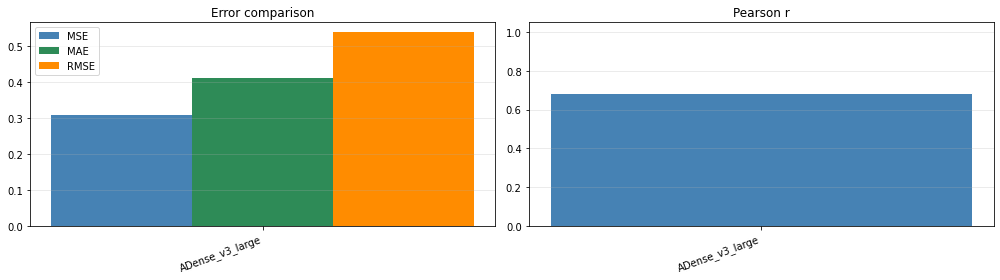

In [12]:
summary=pd.DataFrame(all_variant_results)[['note','model_type','n_params','MSE','MAE','RMSE','r']]
summary=summary.sort_values('MAE').reset_index(drop=True)
print(summary.to_string(index=False,float_format='{:.4f}'.format))

fig,axes=plt.subplots(1,2,figsize=(14,4))
notes=[r['note'] for r in all_variant_results]
x=np.arange(len(notes)); w=0.25
axes[0].bar(x-w,[r['MSE']  for r in all_variant_results],w,label='MSE', color='steelblue')
axes[0].bar(x,  [r['MAE']  for r in all_variant_results],w,label='MAE', color='seagreen')
axes[0].bar(x+w,[r['RMSE'] for r in all_variant_results],w,label='RMSE',color='darkorange')
axes[0].set_xticks(x); axes[0].set_xticklabels(notes,rotation=20,ha='right')
axes[0].set_title('Error comparison'); axes[0].legend(); axes[0].grid(axis='y',alpha=0.3)
axes[1].bar(x,[r['r'] for r in all_variant_results],color='steelblue',edgecolor='white')
axes[1].set_xticks(x); axes[1].set_xticklabels(notes,rotation=20,ha='right')
axes[1].set_ylim(0,1.05); axes[1].set_title('Pearson r'); axes[1].grid(axis='y',alpha=0.3)
plt.tight_layout()



![MAE of Experiments](img/image.png)

![Plots of champion](img/eval_ACNN_v4_nopool.png)

![Plots of champion](img/curves_ACNN_v4_nopool.png)


## Config of champion

batch_size: 32
c_frames: 10
dropout: 0.2
epochs: 120
fc_h: 8
input_dim: 610
kernel_size: 3
lr: 0.001
model_type: cnn
n_features: 61
n_filters: 4
n_params: 1073
patience: 15
pool_size: 1
use_scaling: True


## Results of champion

MAE: 0.34865920543670653

MSE: 0.18644575104117395

n_params: 1073

pearson_r: 0.7496543690111279

## Software

### Timings 

#### No cached models

![No cached models](img/no-cached-timings.png)

#### Cached models

![Cached models](img/cached-timings.png)

### QoL Fixes

- Added drag and drop functionality for files.
- Added timing window to showcase bottlenecks.
- Time limit to remove infinite "Analyzing frames" status on frontend.
- Added scoring model to pipeline.
- Switched from model predicted z-values to MediaPipes z-values for better performance, was half or more of pipeline time.